In [1]:
import sys
sys.path.insert(0, "..")
#------------------------------------------------------------#

import numpy as np
from matplotlib import pyplot as plt
from cmap import Colormap

#=================================================================================================#

from util_functions import interventional as IC
from util_functions import manage_data as md
from util_functions import load_EC as lec
from util_functions import colormaps as maps
from util_functions import plot as pl

plt.rcParams["image.interpolation"] = "none"
plt.rcParams["image.resample"] = False

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
#=================================================================================================#

## Functions

In [2]:
#=================================================================================================#
# For Avenir font. 
# Comment the lines referred to fontManager if you don't need to set the font.
from matplotlib import font_manager, rcParams
font_file   = "../utils/fonts/avenir_ff/AvenirLTStd-Roman.otf"
font_file_b = "../utils/fonts/avenir_ff/AvenirLTStd-Black.otf"
font_file_c = "../utils/fonts/avenir_ff/AvenirLTStd-Book.otf"
font_manager.fontManager.addfont(font_file)
font_manager.fontManager.addfont(font_file_b)
font_manager.fontManager.addfont(font_file_c)
#------------------------------------------------------------#
rcParams['font.family']  = "Avenir LT Std"
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype']  = 42
#------------------------------------------------------------#
DIM = 15
plt.rcParams.update({'font.size': DIM,'axes.labelsize': DIM,'axes.titlesize': DIM,'xtick.labelsize': DIM-6,'ytick.labelsize': DIM-6,
                   'legend.fontsize' : DIM-3})
#=================================================================================================#
# Colors
colorz    = ['#255D93','#5FA6D6','#B02106','#F24D33','#2C2C2C','#787878']
coldhot_cmap   = maps.create_cmaphot()
coldhot_cmap_r = maps.create_cmaphot_r()
#------------------------------------------------------------#
show_plot   = True
#=================================================================================================#

In [3]:
my_palettes = {'1':['#B3D69B', '#455D51', '#D8C27A', '#42AD70', '#284229', '#93CB5B'],
               '2':['#B28CF0', '#F6A3B1', '#8CCCF0', '#F6BB37', '#F3B3B4', '#36B7D2'],
               '3':['#29B4B0', '#F6753C', '#3CAF71'],
               '4':['#EF5840', '#187060', '#6EB0C6'],
               '5':['#4D7B7A', '#9B83C5', '#B2ACA7'],
               '6':['#C46CE8', '#1A63E0', '#6EE4D6'],
               '7':['#F04C45', '#FAD25A', '#F08FB5'],
               '8':['#E14E2D', '#EBAF29', '#498DC4'],
               '9':['#6B8BD4', '#FD5A40', '#45742D'],
               '10':['#D64444', '#FFBEA8', '#43A4C4', '#42708F'],
               }


In [4]:
def Cmap(cmap):
    return Colormap(cmap).to_mpl()

def truncate_cmap(cmap, minval=0.0, maxval=1, n=256):
    from matplotlib.colors import Normalize, LinearSegmentedColormap
    return LinearSegmentedColormap.from_list( f'{cmap.name}_trunc', cmap(np.linspace(minval, maxval, n)) )

def discrete_cmap(cmap_name='turbo', num_colors=25, minval=0., maxval=1):
    from matplotlib.colors import ListedColormap
    base = truncate_cmap(plt.get_cmap(cmap_name), minval=minval, maxval=maxval)
    return ListedColormap(base(np.linspace(0, 1, num_colors)))

# to create folder
def Set_Dir(path):
    import os
    if not os.path.exists(path):
        os.mkdir(path)

In [5]:
def get_col_post_auto(i_rec, sorted_units, counts_dict, bin_sz, pre_start, pre_stop, post_start, post_stop, col_u, col_d, col_n, pre_guard=0.12, peak_win=0.05, late_start=0.15, z_thr=2.0, return_debug=False):
    """
    Pairwise motif classification (independent per stim channel).

    For each stim channel u:
      1) m_u(t) = mean across trials of receiver i_rec
      2) base_u = mean in pre window
      3) m_shift_u(t) = m_u(t) - base_u
      4) noise_u = std of m_shift_u in pre window
      5) early_peak = max in early post window
         late_mean  = mean in late post window

    Decision (local, no across-channel thresholds):
      - E if early_peak > z_thr*noise and late_mean < -z_thr*noise
      - S if late_mean < -z_thr*noise
      - B otherwise
    """
    u0 = sorted_units[0]
    T = counts_dict[u0][0].shape[0]
    t = np.arange(T) * bin_sz

    pre_mask = (t >= pre_start) & (t < pre_stop - pre_guard)
    early_mask = (t >= post_start) & (t < post_start + peak_win)
    late_mask = (t >= post_start + late_start) & (t < post_stop)

    if not (pre_mask.any() and early_mask.any() and late_mask.any()):
        raise ValueError("Empty pre/early/late window. Check timing parameters.")

    cols, labels = [], []
    dbg = {"early_peak": [], "late_mean": [], "noise": [], "z_early": [], "z_late": []}

    for u in sorted_units:
        X = np.stack([counts_dict[u][n][:, i_rec] for n in range(len(counts_dict[u]))], axis=0)  # (Ntrials, T)
        m = X.mean(axis=0)

        base = m[pre_mask].mean()
        m_shift = m - base

        pre_seg = m_shift[pre_mask]
        noise = pre_seg.std(ddof=1) + 1e-12  # local noise scale

        early_peak = m_shift[early_mask].max()
        late_mean = m_shift[late_mask].mean()

        z_early = early_peak / noise
        z_late = -late_mean / noise  # positive if suppression

        is_exc = z_early > z_thr
        is_supp = z_late > z_thr

        if is_exc and is_supp:
            cols.append(col_u); labels.append("exc_then_supp")
        elif is_supp:
            cols.append(col_d); labels.append("suppressed")
        else:
            cols.append(col_n); labels.append("baseline")

        if return_debug:
            dbg["early_peak"].append(early_peak)
            dbg["late_mean"].append(late_mean)
            dbg["noise"].append(noise)
            dbg["z_early"].append(z_early)
            dbg["z_late"].append(z_late)

    if return_debug:
        for k in dbg:
            dbg[k] = np.asarray(dbg[k], dtype=float)
        return cols, labels, dbg

    return cols, labels


# Parameters

In [6]:
main_path     = '../Data_MaxOne/'

# figures folder
Set_Dir('../Figures/')
path_imgs     = '../Figures/Fig2/'
Set_Dir(path_imgs)

sim_folder       = 'Culture1REC1/'
path_IC_data     = main_path+sim_folder+'IC_Data/'
path_ICbin_data  = main_path+sim_folder+'IC_bin_Data/'
Set_Dir(path_IC_data)
Set_Dir(path_ICbin_data)

sim_folder2      = 'Culture2REC1/'
path_IC_data2    = main_path+sim_folder2+'IC_Data/'
path_ICbin_data2 = main_path+sim_folder2+'IC_bin_Data/'
Set_Dir(path_IC_data2)
Set_Dir(path_ICbin_data2)


In [7]:
#=== parameters spontaneous activity ===#

# MaxOne sampling frequency
fs         = 20000     # (Hz)
ms_bins    = 20        # number of samples in a ms

# recording length (min)
T_spont    = 30

# binsize for spike times (ms)
binsize    = 0.3 

#=== parameters evoked activity ===#
Ntrials    = 200
Ntrials2   = 185
DeltaT_sec = 4  #trial duration

# pre– and post–stimulation time windows
Tmax       = 500 * ms_bins # 500
Delta_post = 1 * ms_bins   # 1 
Delta_pre  = 3 * ms_bins   # 3

# binning size for spike count
dT         = 100 * ms_bins
Nbins      = Tmax // dT

# stim. window-length
stim_start = 1000 * ms_bins    # onset of the stimulus
stim_stop  = 1115 * ms_bins    # end of the stimulus

# P-value threshold for EC and IC
alpha_th   = 0.05

# Data load 

## Map of recording channels

In [8]:
# map features: 
# channel: channel IDs
# cluster: cluster IDx for channel groups - 3x3 grid (related to channel array)
# pos:     coordinates of channels (related to channel array)

# map features – culture 1
_, channel, _, pos, cluster, _, _, rate = md.load_original_data(main_path, sim_folder+'/Data/')
channel = channel - 1

# map features – culture 2
_, channel2, _, pos2, cluster2, _, _, rate2 = md.load_original_data(main_path, sim_folder2+'/Data/')
channel2 = channel2 - 1

M  = np.argsort(pos[:,0]) # to sort channels order by x coordinate
M2 = np.argsort(pos2[:,0])


## 1.1 evoked activity experimental block – features load

#### load

In [9]:
#=================================================================================================#
#          s t i m u l a t i o n   e x p e r i m e n t   –   D A T A   L O A D I N G

import pickle
#== evoked activity experimental block - load aligned trials
#== do not decomment below: data are not uploaded on github
orig_path  = '/home/tentori/experimental_works/causality/Original_data/Causality/'
path_IC    = orig_path+sim_folder+'electrodes/'  #orig_path+sim_folder+'electrodes/'
with open(path_IC+'def_spikes.pkl', 'rb') as f:
        def_spikes = pickle.load(f) # (n_stim, n_trials, n_channel)

# map of stimulation channels
path_IC   = main_path+sim_folder+'electrodes/'
def_units = np.load(path_IC+'def_units.npy') # units are numbered in a range from 0 to len(stim channels set)
def_chans = np.load(path_IC+'def_chans.npy')
def_elecs = np.load(path_IC+'def_elecs.npy')

# indexes related to stimulation channels
indices = np.zeros(len(def_chans),dtype=int)
for i in range(len(def_chans)):
    indices[i] = int(np.where(channel==def_chans[i])[0][0])

# erase artifacts in stimulation window
erase_spikes = md.erase_artifacts(channel, def_units, def_spikes, Tstim_start_s=1, Tstim_duration_s=0.115, Tonset_duration=0., 
                               erase_min=1.00-0.003, erase_max=1.117, erase_first=0.0, ipi_sec=0.001, Ntrials=Ntrials, fs=20000)

# Load evoked-activity
spikeTimes, spikeChannels = md.stack_trials(channel, def_units, erase_spikes, T_spont=0, DeltaT_sec=4., Ntrials=Ntrials)
spikes=(spikeTimes/fs,spikeChannels.astype(int))

# compute spike counts
bin_sz=0.01
s_counts = md.compute_spike_counts(spikes, channel=channel, binsize=bin_sz)

In [10]:
#=================================================================================================#
#          s t i m u l a t i o n   e x p e r i m e n t   –   D A T A   L O A D I N G

import pickle
#== evoked activity experimental block - load aligned trials
#== do not decomment below: data are not uploaded on github
orig_path  = '/home/tentori/experimental_works/causality/Original_data/Causality/'
path_IC    = orig_path+sim_folder2+'electrodes/'  #orig_path+sim_folder+'electrodes/'
with open(path_IC+'def_spikes.pkl', 'rb') as f:
        def_spikes2 = pickle.load(f) # (n_stim, n_trials, n_channel)

# map of stimulation channels
path_IC   = main_path+sim_folder2+'electrodes/'
def_units2 = np.load(path_IC+'def_units.npy') # units are numbered in a range from 0 to len(stim channels set)
def_chans2 = np.load(path_IC+'def_chans.npy')
def_elecs2 = np.load(path_IC+'def_elecs.npy')

# indexes related to stimulation channels
indices2 = np.zeros(len(def_chans2),dtype=int)
for i in range(len(def_chans2)):
    indices2[i] = int(np.where(channel2==def_chans2[i])[0][0])

# erase artifacts in stimulation window
erase_spikes2 = md.erase_artifacts(channel2, def_units2, def_spikes2, Tstim_start_s=1, Tstim_duration_s=0.115, Tonset_duration=0., 
                               erase_min=1.00-0.003, erase_max=1.117, erase_first=0.0, ipi_sec=0.001, Ntrials=Ntrials2, fs=20000)

# Load evoked-activity
spikeTimes2, spikeChannels2 = md.stack_trials(channel2, def_units2, erase_spikes2, T_spont=0, DeltaT_sec=4., Ntrials=Ntrials2)
spikes2=(spikeTimes2/fs,spikeChannels2.astype(int))

# compute spike counts
bin_sz=0.01
s_counts2 = md.compute_spike_counts(spikes2,channel=channel2, binsize=bin_sz)


#### plot spike counts

Text(0.5, 1.0, 'Culture 2')

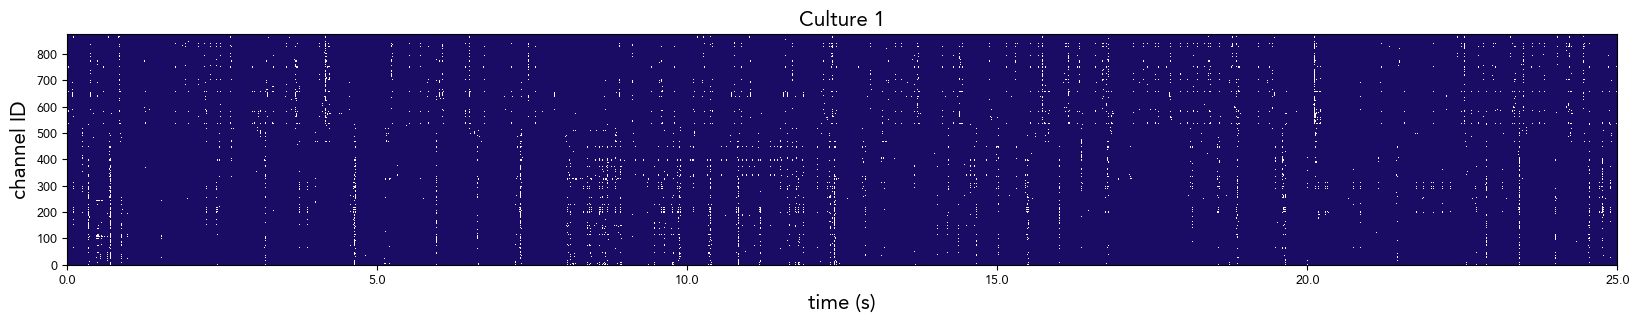

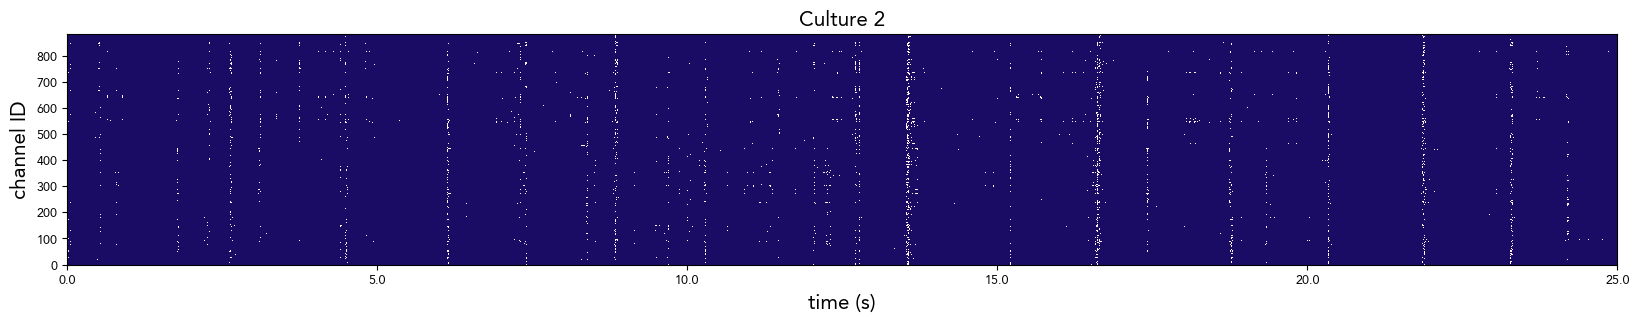

In [11]:
t    = np.arange(s_counts.shape[0])*bin_sz 
fig,ax = plt.subplots(figsize=(20,3))
ax.imshow((s_counts[(t<25)].T)[np.argsort(pos[:,0]),:],aspect='auto', cmap=Cmap('lapaz'),vmin=0, vmax=0.1,)
ax.invert_yaxis()
ax.set_ylabel('channel ID')
ax.set_xlabel('time (s)')
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x * bin_sz:.1f}" for x in xticks])
ax.set_xlim(0/bin_sz,25/bin_sz)
ax.set_title('Culture 1')

t    = np.arange(s_counts2.shape[0])*bin_sz 
fig,ax=plt.subplots(figsize=(20,3))
ax.imshow(s_counts2[(t<25)].T,aspect='auto', cmap=Cmap('lapaz'),vmin=0, vmax=0.1,)
ax.invert_yaxis()
ax.set_ylabel('channel ID')
ax.set_xlabel('time (s)')
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x * bin_sz:.1f}" for x in xticks])
ax.set_xlim(0/bin_sz,25/bin_sz)
ax.set_title('Culture 2')

## 1.2 effective connectivity (EC)

TE computed from 30 mins spontaneous activity.

In [12]:
# CULTURE 1
_TE,  _TE_sign,  _zTE,  _zTE_sign, _TE_Pval   = lec.load_complete_measures(main_path, sim_folder, folder_prefix='ECdata_', file_prefix='Cult_'+str(T_spont)+'min_', ECmeas = 'TE',  tp = 'pk', alpha=alpha_th)
# limiting positive values
thresholdsP = [-7.2, 0., -7.5]; thr_noSig_P = [-7.2, 0., -7.5]
cond = (_TE<10**thr_noSig_P[0]); _TE[cond]=0; del cond; cond = (_TE_sign<10**thresholdsP[0]); _TE_sign[cond]=0;  del cond
# (source x target) IC matrix has size: (nStimChannels, nChannels) – To compare EC with IC - we restrict (source x target) EC matrices from (nChannels, nChannels) to (nStimChannels, nChannels)
TE   = _TE[indices,:];  TE_sign = _TE_sign[indices,:];  
zTE = _zTE[indices,:];  zTE_sign = _zTE_sign[indices,:]; TE_Pval = _TE_Pval[indices,:];
# distance matrix
dist_mat = (lec.load_mat(main_path, sim_folder, binsize=0.3, file_prefix='Cult_'+str(T_spont)+'min_', folder_prefix='ECdata_TE', ECmeas='DistanceMat', suffix='', mat_type='mat_d'))/1000
Dmat     = dist_mat[indices,:]

In [13]:
# CULTURE 2
_TE2,  _TE_sign2,  _zTE2,  _zTE_sign2, _TE_Pval2   = lec.load_complete_measures(main_path, sim_folder2, folder_prefix='ECdata_', file_prefix='Cult_'+str(T_spont)+'min_', ECmeas = 'TE',  tp = 'pk', alpha=alpha_th)
# limiting positive values
thresholdsP = [-7.5, 0., -6.2]; thr_noSig_P = [-7.5, 0., -7]
cond = (_TE2<10**thr_noSig_P[0]); _TE2[cond]=0; del cond; cond = (_TE_sign2<10**thresholdsP[0]); _TE_sign2[cond]=0;  del cond
# (source x target) IC matrix has size: (nStimChannels, nChannels) – To compare EC with IC - we restrict (source x target) EC matrices from (nChannels, nChannels) to (nStimChannels, nChannels)
TE2  = _TE2[indices2,:];  TE_sign2 = _TE_sign2[indices2,:];  
zTE2 = _zTE2[indices2,:]; zTE_sign2 = _zTE_sign2[indices2,:]; TE_Pval2 = _TE_Pval2[indices2,:];
# distance matrix
dist_mat2 = (lec.load_mat(main_path, sim_folder2, binsize=0.3, file_prefix='Cult_'+str(T_spont)+'min_', folder_prefix='ECdata_TE', ECmeas='DistanceMat', suffix='', mat_type='mat_d'))/1000
Dmat2     = dist_mat2[indices2,:]

## 1.3 interventional connectivity (IC)

In [14]:
#load data

# culture 1
ks, ks_pval, _ = IC.ic_load(path_IC_data)
ks_sign     = np.copy(ks); ks_sign[ks_pval>alpha_th] = 0

# culture 2
ks2, ks_pval2, _ = IC.ic_load(path_IC_data2)
ks_sign2     = np.copy(ks2); ks_sign2[ks_pval2>alpha_th] = 0


#### plot matrices

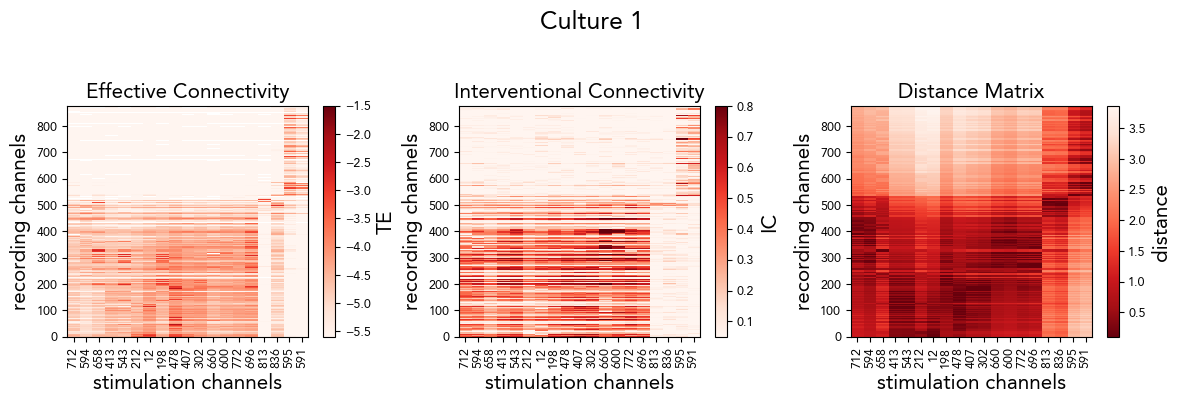

In [15]:
fig,axs = plt.subplots(1,3,figsize=(14,3))
pl.plot_mat_aspect(np.log10(TE[:,M]).T, cmap='Reds', title='Effective Connectivity', ylabel='recording channels', xlabel='stimulation channels', 
                   tick_rotation=90, cbarlabel='TE', xticklabels=indices, ax=axs[0], vmin=-5.6, vmax=-1.5, ticksize=9)
pl.plot_mat_aspect(ks[:,M].T, cmap='Reds', title='Interventional Connectivity', ylabel='recording channels', xlabel='stimulation channels', 
                   tick_rotation=90, cbarlabel='IC', xticklabels=indices, ax=axs[1], vmin=0.05,vmax=0.8, ticksize=9)
pl.plot_mat_aspect(Dmat[:,M].T, cmap='Reds_r', title='Distance Matrix', ylabel='recording channels', xlabel='stimulation channels', 
                   tick_rotation=90, cbarlabel='distance', xticklabels=indices, ax=axs[2], vmin=0.1, ticksize=9)
fig.subplots_adjust(wspace=0.3)
fig.suptitle('Culture 1',y=1.2)
fig.savefig(path_imgs + f'_mats_cult1.pdf', bbox_inches='tight')


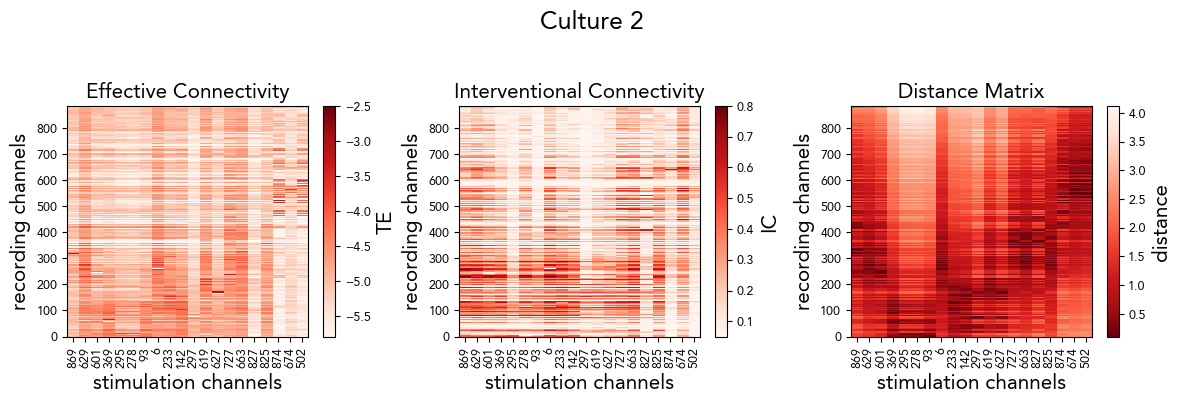

In [16]:
fig,axs = plt.subplots(1,3,figsize=(14,3))
pl.plot_mat_aspect(np.log10(TE2[:,M2]).T, cmap='Reds', title='Effective Connectivity', ylabel='recording channels', xlabel='stimulation channels', 
                   tick_rotation=90, cbarlabel='TE', xticklabels=indices2, ax=axs[0], vmin=-5.8, vmax=-2.5, ticksize=9)
pl.plot_mat_aspect(ks2[:,M2].T, cmap='Reds', title='Interventional Connectivity', ylabel='recording channels', xlabel='stimulation channels', 
                   tick_rotation=90, cbarlabel='IC', xticklabels=indices2, ax=axs[1], vmin=0.05,vmax=0.8, ticksize=9)
pl.plot_mat_aspect(Dmat2[:,M2].T, cmap='Reds_r', title='Distance Matrix', ylabel='recording channels', xlabel='stimulation channels', 
                   tick_rotation=90, cbarlabel='distance', xticklabels=indices2, ax=axs[2], vmin=0.1, ticksize=9)
fig.subplots_adjust(wspace=0.3)
fig.suptitle('Culture 2',y=1.2)
fig.savefig(path_imgs + f'_mats_cult2.pdf', bbox_inches='tight')

## 1.4 compute spike counts

In [17]:
# CULTURE 1
# store the spike counts for each stim unit and for each trial
# counts_dict: pre + stim + post  blocks are consecutive 

counts_dict = {}
for bin_sz in [0.01]:
    # compute spike counts
    s_counts = md.compute_spike_counts(spikes, channel=channel, binsize=bin_sz)
    counts_dict[bin_sz] = {}
    
    trial_block = len(def_units)*DeltaT_sec
    for i_unit in range(len(def_units)):
        counts_dict[bin_sz][i_unit] = {}
        for n in range(Ntrials):
            tbin_min = int(int(trial_block) * n + int(DeltaT_sec) * i_unit ) * int(1/bin_sz)
            tbin_max = int(int(trial_block) * n + int(DeltaT_sec) * i_unit ) * int(1/bin_sz) + int(3.8/bin_sz)
            counts_dict[bin_sz][i_unit][n] = (s_counts[tbin_min:tbin_max,:])

#---------

# CULTURE 2
# store the spike counts for each stim unit and for each trial
# counts_dict: pre + stim + post  blocks are consecutive 

counts_dict2 = {}
for bin_sz in [0.01]:
    # compute spike counts
    s_counts2 = md.compute_spike_counts(spikes2, channel=channel2, binsize=bin_sz)
    counts_dict2[bin_sz] = {}
    
    trial_block = len(def_units2)*DeltaT_sec
    for i_unit in range(len(def_units2)):
        counts_dict2[bin_sz][i_unit] = {}
        for n in range(Ntrials2):
            tbin_min = int(int(trial_block) * n + int(DeltaT_sec) * i_unit ) * int(1/bin_sz)
            tbin_max = int(int(trial_block) * n + int(DeltaT_sec) * i_unit ) * int(1/bin_sz) + int(3.8/bin_sz)
            counts_dict2[bin_sz][i_unit][n] = (s_counts2[tbin_min:tbin_max,:])


# Figure 2 - panels:

Channel response to different perturbations

## a) Channel maps

### channel map

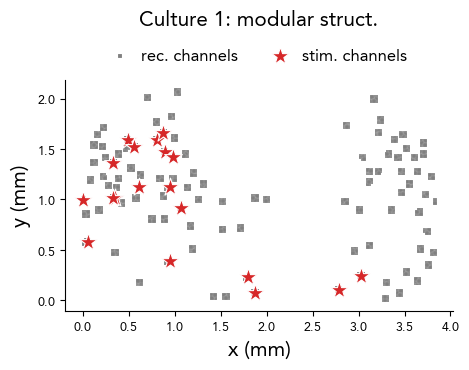

In [18]:
pl.plot_channel_map(pos, channel, def_chans, indices, star_color='tab:red', chsize=10, ch_color='gray', ch_lw=0.1,
                   starsize=180, star_lw=0.8, star_ec='w', ncol_leg=2, y_leg=1.2, title='Culture 1: modular struct.',
                   outf=path_imgs+f'_channel_map_cult1.pdf')


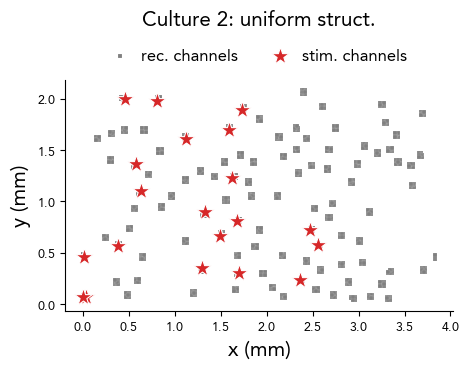

In [19]:
pl.plot_channel_map(pos2, channel2, def_chans2, indices2, star_color='tab:red', chsize=10, ch_color='gray', ch_lw=0.1,
                    starsize=180, star_lw=0.8, star_ec='w', ncol_leg=2, y_leg=1.2, title='Culture 2: uniform struct.',
                  outf=path_imgs+f'_channel_map_cult2.pdf')

### channel map – rec channels highlighted 

In [20]:
#----------------------------
# edge colors
col_d = 'w'; col_u = 'k'; col_n = 'k'
ec_702 = [col_u, col_u, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n][::-1]
ec_367 = [col_n, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_d, col_n, col_n, col_n, col_n, col_n, col_n, col_d][::-1]
ec_539 = [col_u, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_n, col_n]
ec_4   = [col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_d, col_n, col_n, col_d]

# line widths
col_d = 0.4; col_u = 0.3; col_n = 0.3
lw_702 = [col_u, col_u, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n][::-1]
lw_367 = [col_n, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_d, col_n, col_n, col_n, col_n, col_n, col_n, col_d][::-1]
lw_539 = [col_u, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_n, col_n]
lw_4   = [col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_d, col_n, col_n, col_d]

#blue, turquoise, lightblue
col_d = '#1D4FAD'; col_u = '#36B7E9'; col_n = '#AFAFAF'
col_645 = [col_d, col_u, col_u, col_u, col_u, col_u, col_n, col_d, col_n, col_d, col_u,col_u,col_u,col_u,col_u, col_d, col_u, col_n,col_n][::-1]
col_702 = [col_u, col_u, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n][::-1]
col_367 = [col_n, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_d, col_n, col_n, col_n, col_n, col_n, col_n, col_d][::-1]
col_667 = [col_d, col_u, col_d, col_d, col_u, col_d, col_d, col_d, col_u, col_d, col_u, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_n][::-1]
col_539 = [col_u, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_n, col_n]
col_4   = [col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_d, col_n, col_n, col_d]


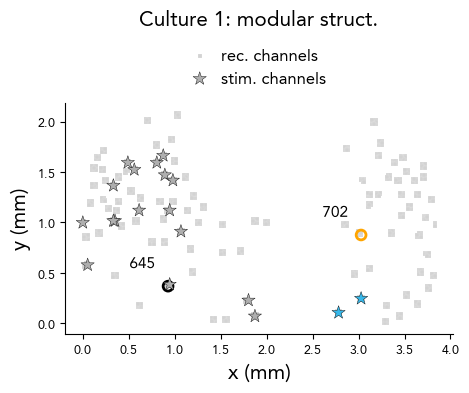

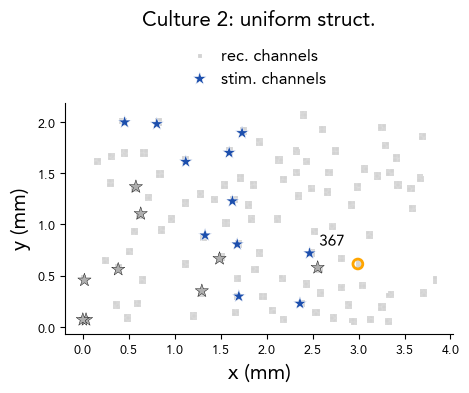

In [21]:
# Plot maps
star_col = col_702
ec_star  = ec_702
pl.plot_channel_map(pos, channel, def_chans, indices, rec_list=[645,702], star_color=star_col, chsize=10, ch_color='lightgrey', ch_lw=0.1,
                    recsize=50,  rec_color='none', rec_lw=2,  rec_ec=['k','orange'],  rec_text=True, text_dim=DIM-4, 
                    starsize=100, star_lw=lw_702, star_ec=ec_star, ncol_leg=1, y_leg=1.3, title='Culture 1: modular struct.',
                   outf=path_imgs+f'A._channel_map_cult1.pdf')

star_col = col_367
ec_star  = ec_367
pl.plot_channel_map(pos2,  channel2, def_chans2, indices2, rec_list=[367], star_color=star_col, chsize=10, ch_color='lightgrey', ch_lw=0.1,
                    recsize=50,  rec_color='none', rec_lw=2,  rec_ec='orange',  rec_text=True, text_dim=DIM-4, 
                    starsize=100, star_lw=lw_367, star_ec=ec_star, ncol_leg=1, y_leg=1.3, title='Culture 2: uniform struct.',
                   outf=path_imgs+f'A._channel_map_cult2.pdf')


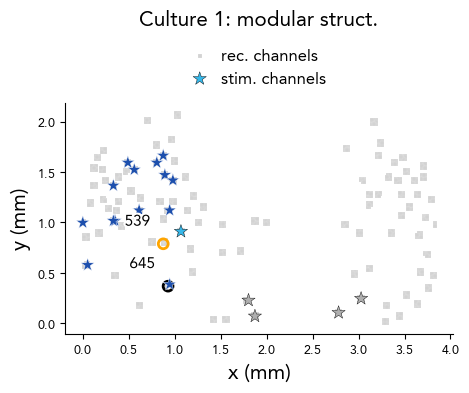

In [22]:
# Plot maps
star_col = col_539
ec_star  = ec_539
pl.plot_channel_map(pos, channel, def_chans, indices, rec_list=[645, 539], star_color=star_col, chsize=10, ch_color='lightgrey', ch_lw=0.1,
                    recsize=50,  rec_color='none', rec_lw=2,  rec_ec=['k','orange'],  rec_text=True, text_dim=DIM-4, 
                    starsize=100, star_lw=lw_702, star_ec=ec_star, ncol_leg=1, y_leg=1.3, title='Culture 1: modular struct.')


## b) scatter IC(stim–>rec) as a function of distance

Focus on single recording channel

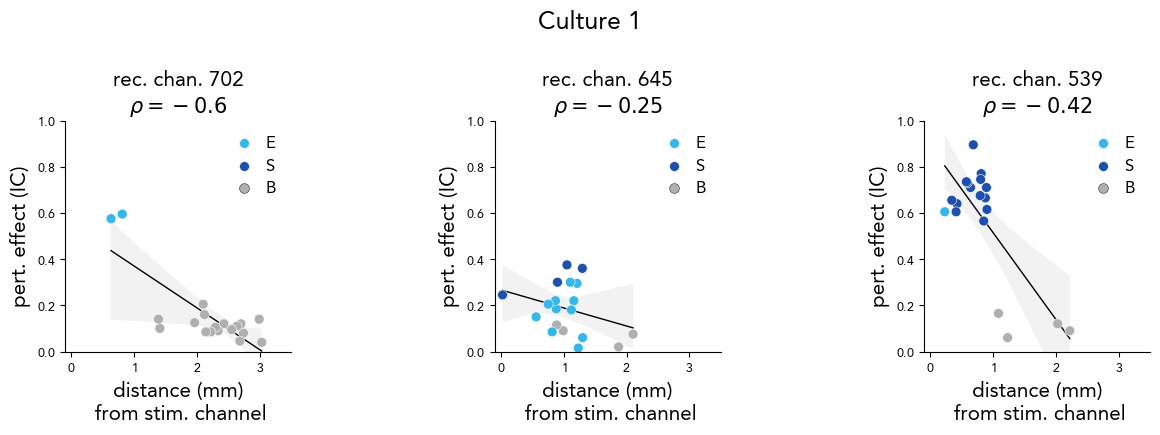

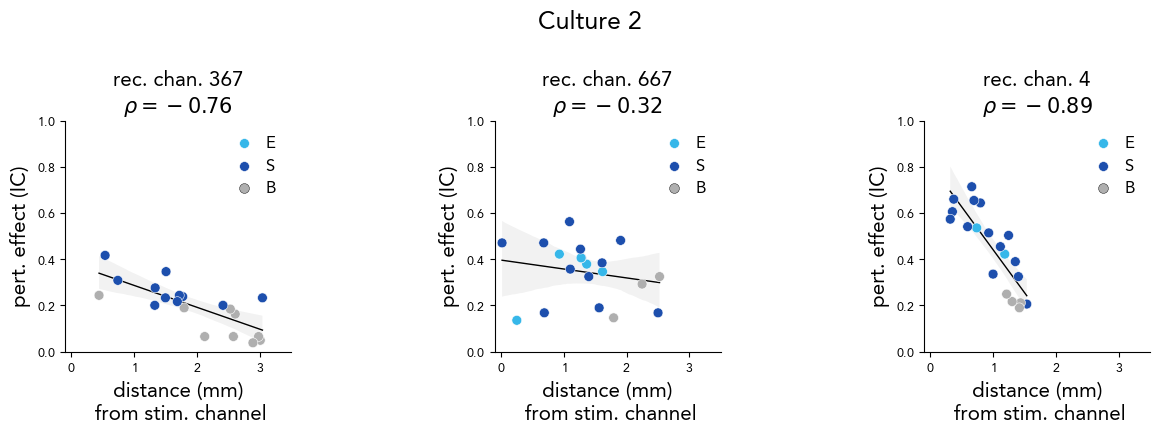

In [23]:
dotsize = 100; KS = ks
col_645 = [col_d, col_u,col_u,col_u,col_u,col_u, col_n, col_d, col_n, col_d, col_u,col_u,col_u,col_u,col_u, col_d, col_u, col_n,col_n][::-1]
col_702 = [col_u, col_u, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n][::-1]
col_539 = [col_u, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_n, col_n][::-1]

col_367 = [col_n, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_d, col_n, col_n, col_n, col_n, col_n, col_n, col_d][::-1]
col_667 = [col_d, col_u, col_d, col_d, col_u, col_d, col_d, col_d, col_u, col_d, col_u, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_n][::-1]
col_4   = [col_d, col_d, col_d, col_d, col_d, col_d, col_u, col_d, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_d, col_n, col_n, col_d][::-1]

show_corr = True
reg_line  = False
regcolor  = 'k'
reg_line  = True

for KS, rec_chans, rec_cols, cult_save, cult_lab, _channel, _pos, _def_units, _def_chans in zip([ks,ks2],[[702,645, 539],[367, 667, 4]], 
                                                                                                [[col_702,col_645,col_539],[col_367,col_667,col_4]],
                                                                                                ['culture1','culture2'], 
                                                                                                ['Culture 1','Culture 2'], 
                                                                                                [channel,channel2], [pos,pos2], 
                                                                                                [def_units,def_units2], 
                                                                                                [def_chans,def_chans2] ):

    fig,axs = plt.subplots(1,3,figsize=(14,3))
    for i_rec, col_post,ax in zip(rec_chans, rec_cols, axs):
        pl.plot_scatter_dots(KS, i_rec, col_post, cult_lab, _channel, _pos, _def_units, _def_chans, show_corr = True, ec='w', lw=0.4,
                          ymax=1,ymin=0, title=f'rec. chan. {i_rec}', regcolor  = 'k', reg_line=True, ax=ax)
        for i, c, ec, lw, lab in zip(np.arange(3),[col_u,col_d,col_n],['w','w','k'],[0.4,0.4,0.3], ['E','S','B']):
            ax.scatter(-2.8,-0.8-i*0.1,c=c,s=50,ec=ec,lw=lw,label=lab)
            ax.legend(ncol=1,loc='upper right', labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    
            
    fig.subplots_adjust(wspace=0.9)
    fig.suptitle(cult_lab,y=1.25)
    
    if reg_line:
        fig.savefig(path_imgs + f'B._scatterplot_IC_rec{i_rec}_distance_regline_{cult_save}.pdf', bbox_inches='tight')
    else:
        fig.savefig(path_imgs + f'B._scatterplot_IC_rec{i_rec}_distance_{cult_save}.pdf', bbox_inches='tight')


## c1) spiking response

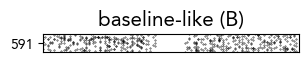

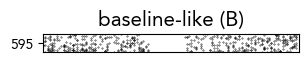

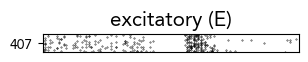

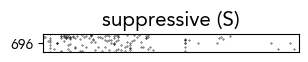

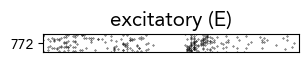

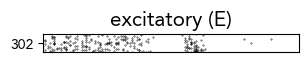

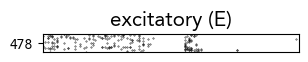

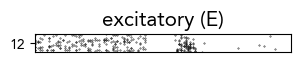

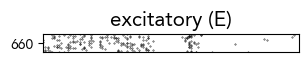

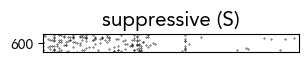

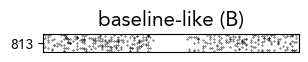

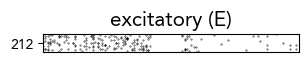

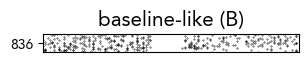

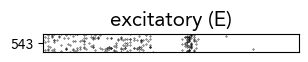

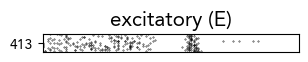

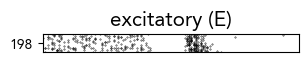

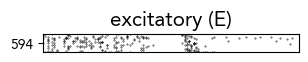

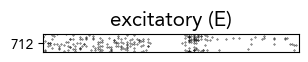

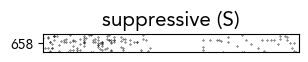

In [24]:
# CULTURE 1
bin_sz = 0.01
colored = False
for i_rec in [645]: # i_rec : recording channel ID
    sorted_units, sorted_d = pl.sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
    col_post_auto, labels, dbg = pl.get_col_post_auto(i_rec=i_rec, sorted_units=sorted_units, counts_dict=counts_dict[bin_sz], bin_sz=bin_sz, pre_start=0.5, pre_stop=0.97, post_start=1.13, post_stop=1.13+0.5, col_u=col_u, col_d=col_d, col_n=col_n, pre_guard=0.12, peak_win=0.05, late_start=0.15, q=0.2, min_post_peak=-0.02, min_dp=-0.02, return_debug=True)

    for i,i_unit in enumerate(sorted_units):
        if np.isin(indices[i_unit], indices):#np.array([658, 198, 595])):
            tot_trial = (counts_dict[bin_sz][i_unit][n])[int(0.5/bin_sz):int(1.62/bin_sz),i_rec]
            fig,ax = plt.subplots(1,1,figsize=(3.3,4.4/len(indices)))
            for n in range(0,Ntrials):
                trial = np.where((counts_dict[bin_sz][i_unit][n])[int(0.5/bin_sz):int(1.62/bin_sz),i_rec]!=0)[0]
                if colored is True:
                    ax.scatter(trial[trial<len(tot_trial)//2], (n+1)*np.ones(len(trial[trial<len(tot_trial)//2])),c=col_n,s=0.1)
                    ax.scatter(trial[trial>=len(tot_trial)//2], (n+1)*np.ones(len(trial[trial>=len(tot_trial)//2])),c=col_post_auto[i],s=0.1)
                else:
                    ax.scatter(trial[trial<len(tot_trial)//2], (n+1)*np.ones(len(trial[trial<len(tot_trial)//2])),c='k',s=0.1)
                    ax.scatter(trial[trial>=len(tot_trial)//2], (n+1)*np.ones(len(trial[trial>=len(tot_trial)//2])),c='k',s=0.1)

            fig.subplots_adjust(hspace=0.4)
            if col_post_auto[i]==col_u:
                ax.set_title(f'excitatory (E)')
            elif col_post_auto[i]==col_d:
                ax.set_title(f'suppressive (S)')
            else:
                ax.set_title(f'baseline-like (B)')

            #ax.set_title(f'stim. chan. {indices[i_unit]}')
            ax.set_xticks([])
            ax.set_yticks([100])
            ax.set_yticklabels([indices[i_unit]],fontsize=DIM-5)
            ax.set_xlim(0,len(tot_trial))
            ax.set_ylim(0,Ntrials)
            #plt.savefig(path_imgs + f'C1._spike_counts{i_rec}_stim{indices[i_unit]}_culture1.pdf', bbox_inches='tight')
            

## c2) traces

In [35]:
w_sum=np.sum([  5,   1,     4.,  1,  5,  1,  4.])
h_sum=np.sum([3,0.7,2,3])
w=(14/w_sum*5)
h=(7/h_sum*5.5)

pre_start  = 0.470
pre_stop   = pre_start+0.5
post_start = 1.12
post_stop  = post_start+0.5
stim0      = 1
stimEnd    = 1.12

bin_sz = 0.01
#blue, red, lightgrey
col_d = '#1D4FAD'; col_u = '#36B7E9'; col_n = '#AFAFAF'

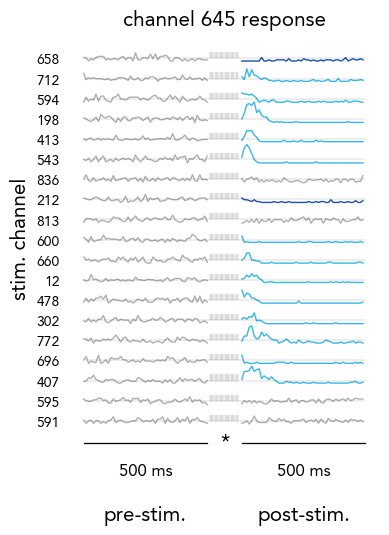

In [36]:
i_rec = 645
col_post = [col_d, col_u,col_u,col_u,col_u,col_u, col_n, col_d, col_n, col_d, col_u,col_u,col_u,col_u,col_u, col_d, col_u, col_n,col_n][::-1]
sorted_units, sorted_d = pl.sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
col_post_auto          = pl.get_col_post_auto(i_rec=i_rec, sorted_units=sorted_units, counts_dict=counts_dict[bin_sz], bin_sz=bin_sz, pre_start=0.4, pre_stop=0.9, post_start=1.12, post_stop=1.12+0.5, col_u=col_u, col_d=col_d, col_n=col_n, pre_guard=0.12, peak_win=0.05, late_start=0.15, q=0.2, min_post_peak=-0.02, min_dp=-0.02)
pl.plot_traces_zoom(i_rec, sorted_units, indices, counts_dict[bin_sz], col_post_auto, col_n, bin_sz=bin_sz, n_ampli=2, font_yticks=DIM-5, Ntrials=Ntrials,
                 pre_start=pre_start, pre_stop=pre_stop, post_start=post_start, post_stop=post_stop, stim0=stim0, stimEnd=stimEnd,
                 figsize=(w*1.2, h*1.2), ax=None, outf=path_imgs + f'C2._spike_mean{i_rec}_culture1.pdf', show_plot=True)


### Traces - plot for longer time

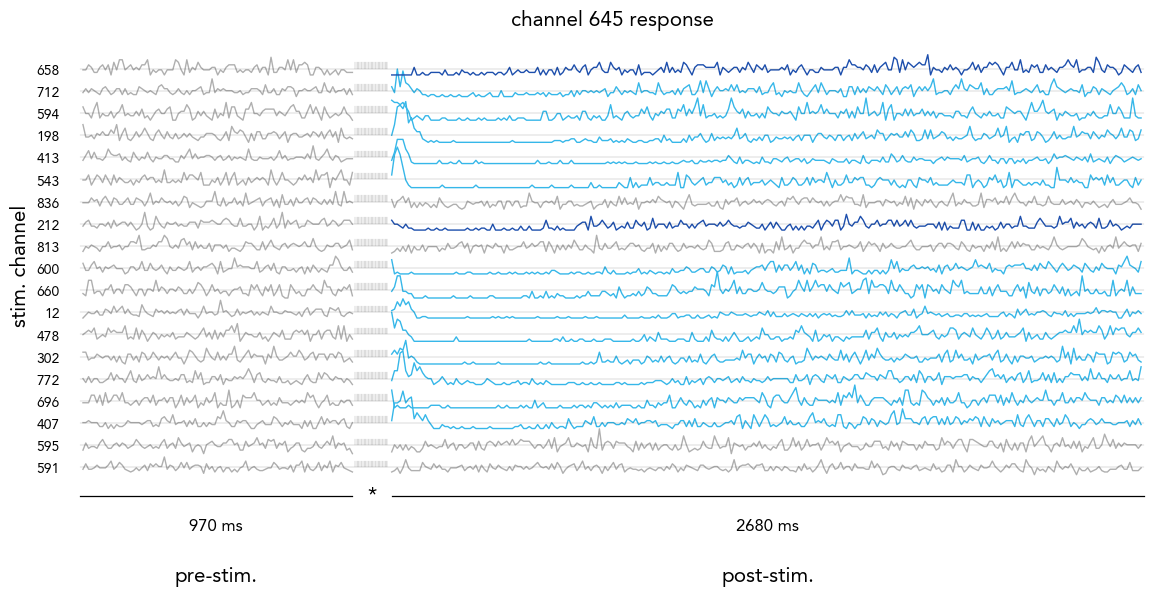

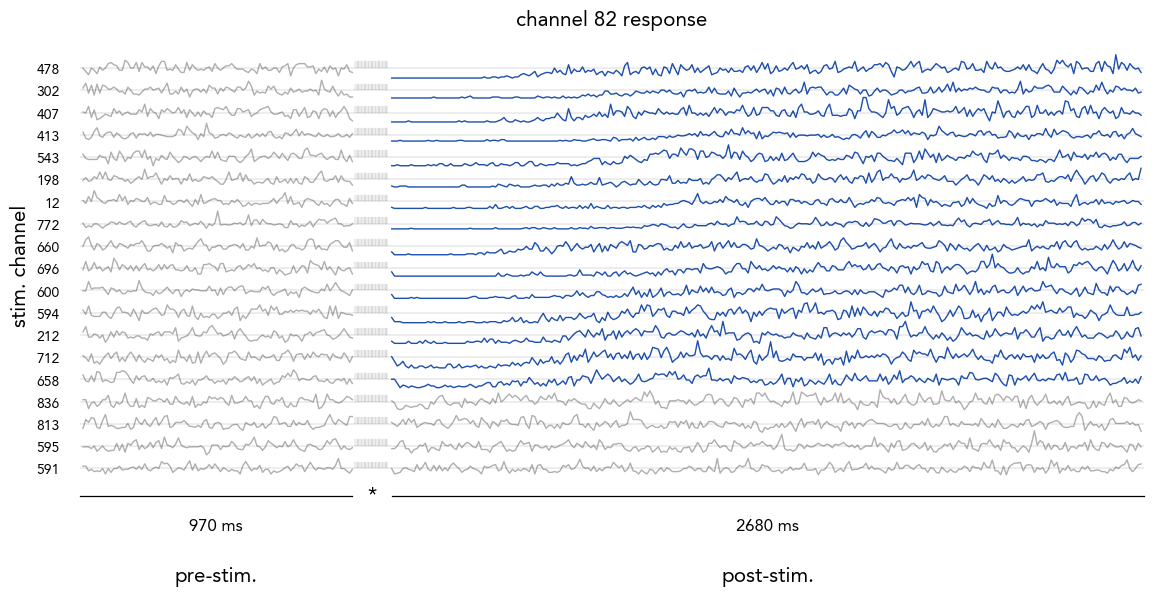

In [37]:
#CUTLURE 1
bin_sz=0.01
for i_rec in [645, 82]:
    sorted_units, sorted_d = pl.sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
    col_post_auto, labels, dbg = pl.get_col_post_auto(i_rec=i_rec, sorted_units=sorted_units, counts_dict=counts_dict[bin_sz], bin_sz=bin_sz,
                                    pre_start=0.4, pre_stop=0.9, post_start=1.12, post_stop=1.12+0.5, col_u=col_u, col_d=col_d, col_n=col_n,
                                    pre_guard=0.12, peak_win=0.05, late_start=0.15, q=0.2, min_post_peak=-0.002, min_dp=-0.002,  return_debug=True)

    pl.plot_traces_zoom(i_rec, sorted_units, indices, counts_dict[bin_sz], col_post_auto, col_n, bin_sz=bin_sz, n_ampli=4, x_margins=0.01,
                pre_start=0, pre_stop=pre_stop, post_start=post_start, post_stop=3.8, stim0=stim0, stimEnd=stimEnd,
                figsize=(14,6), outf=path_imgs+f'_tracesAlltrial_recChan_{i_rec}_bs_{int(bin_sz*1000)}ms_culture1.pdf', show_plot=show_plot)



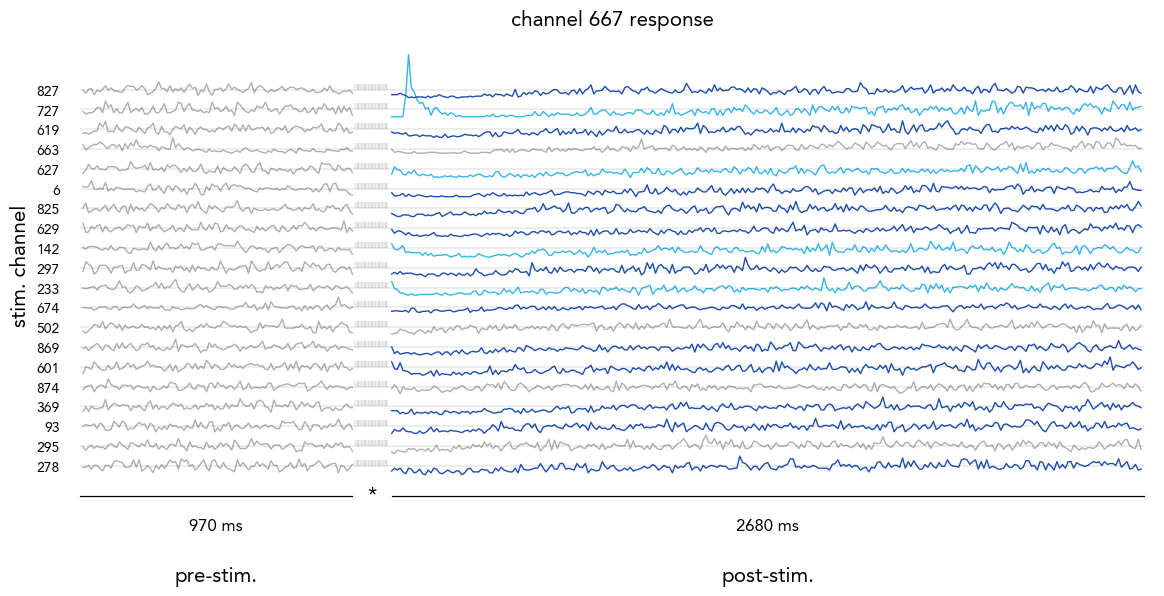

In [38]:
for i,bin_sz in enumerate([0.01]): #,0.02,0.04]):
    i_rec = 667
    col_post = [col_d, col_u, col_d, col_d, col_u, col_d, col_d, col_d, col_u, col_d, 
                col_u, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_n][::-1]
    sorted_units, sorted_d = pl.sort_units_with_distance(i_rec, channel2, pos2, def_units2, def_chans2)


    col_post_auto, labels, dbg = pl.get_col_post_auto(i_rec=i_rec, sorted_units=sorted_units, counts_dict=counts_dict2[bin_sz], bin_sz=bin_sz,
                                    pre_start=0.4, pre_stop=0.9, post_start=1.12, post_stop=1.12+0.5, col_u=col_u, col_d=col_d, col_n=col_n,
                                    pre_guard=0.12, peak_win=0.05, late_start=0.15, q=0.2, min_post_peak=-0.002, min_dp=-0.002,  return_debug=True)

    pl.plot_traces_zoom(i_rec, sorted_units, indices2, counts_dict2[bin_sz], col_post_auto, col_n, bin_sz=bin_sz, n_ampli=4, Ntrials=Ntrials2,
                pre_start=0, pre_stop=pre_stop, post_start=post_start, post_stop=3.8, stim0=stim0, stimEnd=stimEnd, x_margins=0.01,
                figsize=(14,6), outf=path_imgs+f'_tracesAlltrial_recChan_{i_rec}_bs_{int(bin_sz*1000)}ms_culture2.pdf', show_plot=show_plot)


## d) IC(stim–>rec) as function of distance from stim. channel

Focus on 100 rec. channels with highest in-strength

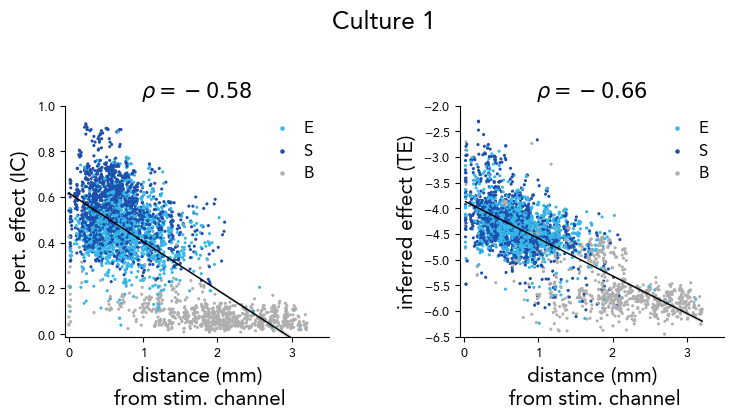

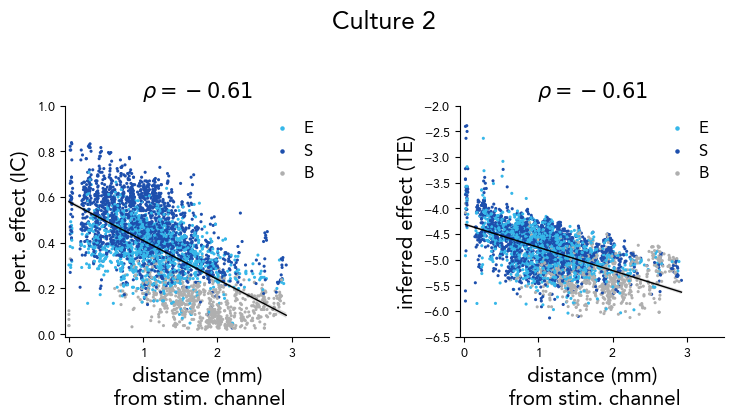

In [29]:
n_chans=200
dotsize = 1000/n_chans
figsize=(8.5,3)
xlabel  = 'distance (mm)\n from stim. channel'
for m,IC_mat, TE_mat, k_dict, cult_save, cult_lab, _channel, _pos, _def_units, _def_chans in zip([-0.02,-0.025],[ks,ks2], [TE,TE2], [counts_dict,counts_dict2],
                                                                                               ['culture1','culture2'], ['Culture 1','Culture 2'], [channel,channel2], [pos,pos2], [def_units,def_units2], [def_chans,def_chans2] ):
    in_sign_bin = np.sum(IC_mat,axis=0)
    L           = np.argsort(in_sign_bin)[::-1]

    fig,axs = plt.subplots(1,2,figsize=figsize)
    for y, lab, log, ax in zip([IC_mat, TE_mat], ['IC','TE'], [False,True], axs):
        if log==False:
            ylabel  = 'pert. effect (IC)'
            pl.plot_scatter_colors(IC_mat, y, k_dict, _channel, _pos, _def_units, _def_chans, n_chans=n_chans, bin_sz=0.01, log=log, xlabel=xlabel, ylabel=ylabel, col_u=col_u, col_n=col_n, col_d=col_d,
                                regcolor='k',lw=0, dotsize=dotsize, ec='grey', title=None, alpha=1, cmap=None, xmin=-0.05, xmax=3.5, ymin=-0.01, ymax=1, ax=ax,
                                  min_dp=m, min_post_peak=m)
        else:
            ylabel  = 'inferred effect (TE)'
            pl.plot_scatter_colors(IC_mat, y, k_dict, _channel, _pos, _def_units, _def_chans, n_chans=n_chans, bin_sz=0.01, log=log, xlabel=xlabel, ylabel=ylabel, col_u=col_u, col_n=col_n, col_d=col_d,
                                regcolor='k', lw=0,dotsize=dotsize, ec='grey', title=None, alpha=1, cmap=None, xmin=-0.05, xmax=3.5,  ymin=-6.5, ymax=-2, ax=ax,
                                  min_dp=m, min_post_peak=m)             
        
        for i, c,lab in zip(np.arange(3),[col_u,col_d,col_n],['E','S','B']):
            if ax == axs[0]:
                ax.scatter(-2.8,-0.8-i*0.1,c=c,s=dotsize,label=lab)
            else:
                ax.scatter(-20,-0.8-i*0.1,c=c,s=dotsize,label=lab)
            ax.legend(ncol=1,loc='upper right', labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    fig.subplots_adjust(wspace=0.5)
    fig.suptitle(cult_lab,y=1.2)
    plt.savefig(path_imgs+f'D._edge_vs_rec_distances_{cult_save}.pdf', bbox_inches='tight')
    

# Figure 2 -  Manuscript

In [30]:
# Plotting the traces. Time windows
pre_start  = 0.470           # (seconds) onset of the pre-stimulation time-window
pre_stop   = pre_start+0.5   # (seconds) offset of the pre-stimulation time-window

stim0      = 1               # (seconds) onset of the stimulation window
stimEnd    = 1.12            # (seconds) offset of the stimulation window

post_start = 1.12            # (seconds) onset of the POST-stimulation time-window
post_stop  = post_start+0.5  # (seconds) offset of the POST-stimulation time-window


bin_sz = 0.01

In [31]:
#----------------------------
# edge colors for suppressive (S), excited (E) and baseline (B) response motifs
col_d = 'w'; col_u = 'w'; col_n = 'k'
ec_702 = [col_u, col_u, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n][::-1]
ec_367 = [col_n, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_d, col_n, col_n, col_n, col_n, col_n, col_n, col_d][::-1]
ec_539 = [col_u, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_n, col_n][::-1]
ec_4   = [col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_d, col_n, col_n, col_d][::-1]
#----------------------------
# line width for suppressive (S), excited (E) and baseline (B) response motifs
col_d = 0.4; col_u = 0.4; col_n = 0.3
lw_702 = [col_u, col_u, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n][::-1]
lw_367 = [col_n, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_d, col_n, col_n, col_n, col_n, col_n, col_n, col_d][::-1]
lw_539 = [col_u, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_n, col_n][::-1]
lw_4   = [col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_d, col_n, col_n, col_d][::-1]
#----------------------------

In [32]:
def plot_map_rec_5(pos_, channel, indices, rec_list=None, cmap=None, cbar_label='', title=None, plot_net=False,
                   ch_color='lightgrey', ch_size=4.5, ch_lw=0.01, ch_label='rec. ch.', dx=150, dy=60,
                   starsize=300, star_color='k', star_lw=0.1, star_ec='white', star_label='stim. ch.',
                   recsize=1350,  rec_color='tab:blue', rec_lw=0.1, rec_ec='white',  rec_label='example', rec_text=True, text_dim=18,
                   ncol_leg=2, y_leg=1.2, y_titl=None, figsize=(5, 3), ax=None, outf : str = None, show_plot = True):
    
    pos = pos_[:,:]/1000

    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
    
    # Full map of recording channels 
    scatter_rec = ax.scatter(pos[:, 0], pos[:, 1], s=ch_size, lw=ch_lw, marker='s', c=ch_color, edgecolor='white',
                             label=ch_label, cmap=cmap, zorder=0)
    if cmap is not None:
        cbar        = fig.colorbar(scatter_rec, ax=ax, label=cbar_label)
    
    # stimulation channels
    scatter = ax.scatter(pos[indices, 0], pos[indices, 1], c=star_color, lw=star_lw,
                         edgecolor=star_ec, s=starsize, marker='*', alpha=1, zorder=1, label=star_label)

    # recording channels to highlight
    if rec_list is not None:
        scatter_rec = ax.scatter(pos[rec_list, 0], pos[rec_list, 1], s=recsize, lw=rec_lw, marker='s', c=rec_color, 
                                 edgecolor=rec_ec, zorder=3, label=rec_label)
    # labels for rec channels 
    import matplotlib.patheffects as pe
    if rec_list is not None and rec_text is True:
        a = 0
        for i_rec in rec_list:
            x = pos[channel == channel[i_rec], 0][0];    y = pos[channel == channel[i_rec], 1][0]
            ax.text(x + dx/1000, y + dy/1000, 'rec. ch. '+str(i_rec),fontdict=dict(color='k', alpha=1, size=text_dim),
                   path_effects=[pe.withStroke(linewidth=3, foreground='white')])
            a += 1
            
    ax.set_xlabel('x (mm)');    ax.set_ylabel('y (mm)')
    #pl.set_format(ax, axis_ticks='both', cbar=None)

    ax.legend(ncol=ncol_leg, loc='upper center', bbox_to_anchor=(0.5, y_leg),
              labelspacing=0.4, handletextpad=0.4, handlelength=.5, frameon=False)
    
    if title:
        if y_titl is None:
            y_titl=y_leg
        ax.set_title(title, y=y_titl)

    fig.set_facecolor('none')
    ax.set_facecolor('none')
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [33]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------#
# colors for suppressive (S), excited (E) and baseline (B) response motifs
col_d = '#1D4FAD'; col_u = '#36B7E9'; col_n = '#AFAFAF'
col_645 = [col_d, col_u,col_u,col_u,col_u,col_u, col_n, col_d, col_n, col_d, col_u,col_u,col_u,col_u,col_u, col_d, col_u, col_n,col_n][::-1]
col_702 = [col_u, col_u, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n][::-1]
col_367 = [col_n, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_d, col_n, col_n, col_n, col_n, col_n, col_n, col_d][::-1]
col_667 = [col_d, col_u, col_d, col_d, col_u, col_d, col_d, col_d, col_u, col_d, col_u, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_n][::-1]
col_539 = [col_u, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_n, col_n][::-1]
col_4   = [col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_d, col_n, col_n, col_d][::-1]


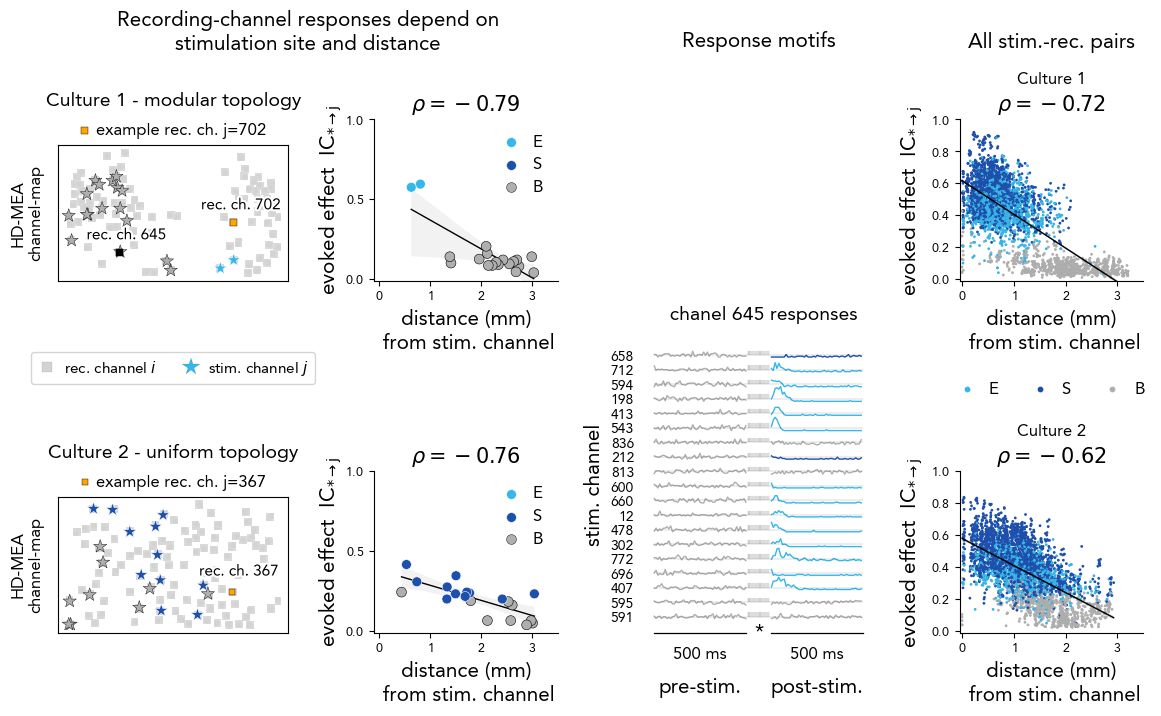

In [34]:
DIM = 15
plt.rcParams.update({'font.size': DIM,'axes.labelsize': DIM,'axes.titlesize': DIM,'xtick.labelsize': DIM-6,'ytick.labelsize': DIM-6,
                   'legend.fontsize' : DIM-3})

#-----------------------------------------------------------------------------------------------------------------------------------------------------------#

ms = [[  '', '',  '', '','c1', '',  ''],
      [  '', '','b1', '','c1', '','d1'],
      ['a1', '','b1', '','c1', '','d1'],
      [  '', '',  '', '',  '', '',  ''],
      [  '', '',  '', '','c2', '',  ''],
      [  '', '',  '', '','c2', '',  ''],
      [  '', '','b2', '','c2', '','d2'],
      ['a2', '','b2', '','c2', '','d2'],]
wr =  [ 5, 0.72, 4., 0.72, 5, 0.72, 4.]
hr = [0.3,0.3,2.8, 0.7, 2, 0.3,0.3, 2.8]

mosaic        = ms
width_ratios  = wr
height_ratios = hr

#-----------------------------------------------------------------------------------------------------------------------------------------------------------#
    
### Plot figure
fig, axs = plt.subplot_mosaic(mosaic, figsize = (14, 7), gridspec_kw = {'width_ratios': width_ratios, 'height_ratios': height_ratios}, empty_sentinel="", constrained_layout=False)

#----------------------------
# Plot maps
ax = axs['a1']
star_col = col_702; ec_star  = ec_702; star_lw=lw_702
plot_map_rec_5(pos, channel, indices, rec_list=[702,645], star_color=star_col, ch_size=15, ch_color='lightgrey', ch_lw=0.1,
               recsize=24,  rec_ec='k', rec_lw=0.3,  rec_color=['orange','k'],  rec_text=True, text_dim=DIM-4, starsize=100, star_lw=star_lw, star_ec=ec_star, dy=+230,dx=-600,
               ch_label=None, star_label=None, rec_label=f'example rec. ch. j=702', ncol_leg=2, y_leg=1.28, ax=ax) 

ax = axs['a2']
star_col = col_367; ec_star  = ec_367; star_lw=lw_367
plot_map_rec_5(pos2, channel2, indices2, rec_list=[367], star_color=star_col, ch_size=15, ch_color='lightgrey', ch_lw=0.1,
               recsize=24,  rec_ec='k', rec_lw=0.3,  rec_color=['orange'],  rec_text=True, text_dim=DIM-4, starsize=100, star_lw=star_lw, star_ec=ec_star, dy=+270,dx=-600,
               ch_label=None, star_label=None, rec_label=f'example rec. ch. j=367', ncol_leg=2, y_leg=1.28,  ax=ax) 

for ax in [axs['a1'],axs['a2']]:
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel('', fontsize=DIM-3, labelpad=10); ax.set_ylabel('HD-MEA\nchannel-map', fontsize=DIM-3, labelpad=10);
    #ax.set_title('HD-MEA channel-map', fontsize=DIM-3,y=1.18); 
axs['a1'].set_title(r'Culture 1 - modular topology', fontsize=DIM-1,y=1.23); 
axs['a2'].set_title(r'Culture 2 - uniform topology', fontsize=DIM-1,y=1.23); 


from matplotlib.lines import Line2D
fig.canvas.draw()
b1 = axs['a1'].get_position(); b2 = axs['a2'].get_position()
x_leg = 0.5 * (b1.x0 + b1.x1); y_leg = 0.5 * (b2.y1 + b1.y0) + 0.03
handles_map = [ Line2D([0], [0], marker='s', linestyle='None', markersize=7, markerfacecolor='lightgrey', markeredgecolor='k', markeredgewidth=0.05, label='rec. channel $i$'),
                Line2D([0], [0], marker='*', linestyle='None', markersize=13, markerfacecolor=col_u, markeredgecolor='k', markeredgewidth=0.05, label='stim. channel $j$')]
leg_map = fig.legend(handles=handles_map, ncol=2, loc='center', bbox_to_anchor=(x_leg, y_leg), frameon=True, 
                     handlelength=1.2, handletextpad=0.5, columnspacing=1.6, borderpad=0.45, fontsize=DIM-4)

''#----------------------------
# Scatter example rec. channels
for KS, rec_chans, rec_cols, ec_cols, cult_save, cult_lab, _channel, _pos, _def_units, _def_chans, _axs in zip([ks,ks2],[[702],[367]],  [[col_702],[col_367]], [[ec_702],[ec_367]], ['culture1','culture2'],  ['Culture 1','Culture 2'], 
                                                                                                [channel,channel2], [pos,pos2],  [def_units,def_units2],  [def_chans,def_chans2], [[axs['b1']],[axs['b2']]]):
    for i_rec, col_post, ec_post, ax in zip(rec_chans, rec_cols, ec_cols, _axs):
        pl.plot_scatter_dots(KS, i_rec, col_post, cult_lab, _channel, _pos, _def_units, _def_chans, show_corr = True, corr='pearson', ec=ec_post, lw=0.4, ymax=1,
                 regcolor='k', reg_line=True, title=None, ax=ax)
        ax.set_ylabel(fr'evoked effect  IC$_{{ \text{{*}} \rightarrow \mathrm{{ j }} }}$', labelpad=0.8)

    for i, c, ec, lw, lab in zip(np.arange(3),[col_u,col_d,col_n],['w','w','k'],[0.4,0.4,0.3], ['E','S','B']):
        ax.scatter(-2.8,-0.8-i*0.1,c=c,s=50,ec=ec,lw=lw,label=lab)
        ax.legend(ncol=1,loc='upper right', labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
        ax.title.set_fontsize(DIM)
    ax.set_yticks([0.0,0.5,1.0])

#----------------------------

fig.canvas.draw(); b1 = axs['a1'].get_position(); b2 = axs['b1'].get_position()
x_center = 0.5 * (b1.x0 + b2.x1) ; y_top    = max(b1.y1, b2.y1) 
fig.text(x_center, y_top + 0.092, 'Recording-channel responses depend on\nstimulation site and distance',  ha='center', va='bottom', fontsize=DIM)

#------------------------------------------------------------------------------------------------------------------------------------

# Plot legend
ax = axs['c1']
pl.despine_ax(ax); ax.set_facecolor('none')
ax.set_xticklabels([]); ax.set_yticklabels([])

fig.canvas.draw(); b1 = axs['c1'].get_position(); b2 = axs['c1'].get_position()
x_center = 0.5 * (b1.x0 + b2.x1) ; y_top    = max(b1.y1, b2.y1) 
fig.text(x_center, y_top + 0.06, 'Response motifs',  ha='center', va='bottom', fontsize=DIM)

#----------------------------

# Plot traces
ax = axs['c2']
i_rec    = 645; bin_sz   = 0.01
col_post = [col_d, col_u,col_u,col_u,col_u,col_u, col_n, col_d, col_n, col_d, col_u,col_u,col_u,col_u,col_u, col_d, col_u, col_n,col_n][::-1]
sorted_units, sorted_d = pl.sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
col_post_auto          = pl.get_col_post_auto(i_rec=i_rec, sorted_units=sorted_units, counts_dict=counts_dict[bin_sz], bin_sz=bin_sz, pre_start=0.4, pre_stop=0.9, post_start=1.12, post_stop=1.12+0.5, col_u=col_u, col_d=col_d, col_n=col_n, pre_guard=0.12, peak_win=0.05, late_start=0.15, q=0.2, min_post_peak=-0.02, min_dp=-0.02)
pl.plot_traces_zoom(i_rec, sorted_units, indices, counts_dict[bin_sz], col_post_auto, col_n, bin_sz=bin_sz, n_ampli=2, font_yticks=DIM-5,
                 pre_start=pre_start, pre_stop=pre_stop, post_start=post_start, post_stop=post_stop, stim0=stim0, stimEnd=stimEnd, ax=ax)
axs['c2'].set_title('  chanel 645 responses', fontsize=DIM-1,y=1.03); 
#------------------------------------------------------------------------------------------------------------------------------------

# Scatter 100 in-strength channels
xlabel  = 'distance (mm)\n from stim. channel'
ylabel  = 'evoked effect (IC)'
for IC_mat, k_dict, ax, cult_lab, _channel, _pos, _def_units, _def_chans,  in zip([ks,ks2], [counts_dict,counts_dict2], [axs['d1'],axs['d2']],
                                                                                  ['Culture 1\n','Culture 2\n'], [channel,channel2], [pos,pos2], 
                                                                                  [def_units,def_units2], [def_chans,def_chans2] ):
    in_sign_bin = np.sum(IC_mat,axis=0)
    L           = np.argsort(in_sign_bin)[::-1]
    
    pl.plot_scatter_colors(IC_mat, IC_mat, k_dict, _channel, _pos, _def_units, _def_chans, bin_sz=bin_sz, log=False, reg_line=True, regcolor='k',
                        xlabel=xlabel, ylabel=ylabel,  dotsize=4, lw=0.01, ec='grey', title=None, alpha=1, n_chans=200, show_corr = True, corr='pearson',
                        min_post_peak=-0.02, min_dp=-0.02, xmin=-0.05, xmax=3.5, ymin=-0.01, ymax=1, ax=ax, col_u=col_u, col_d=col_d, col_n=col_n)
    ax.set_ylabel(r'evoked effect  IC$_{ \text{*} \rightarrow \mathrm{j} }$ ')

    
    for i, c,lab in zip(np.arange(3),[col_u,col_d,col_n],['E','S','B']):
        ax.scatter(-2.8,-0.8-i*0.1,c=c,s=10,label=lab)
    ax.title.set_fontsize(DIM)

ax.legend(ncol=3,loc='upper center', bbox_to_anchor=(0.5, 1.65), labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)

fig.canvas.draw(); b1 = axs['d1'].get_position(); b2 = axs['d1'].get_position()
x_center = 0.5 * (b1.x0 + b2.x1) ; y_top    = max(b1.y1, b2.y1) 
fig.text(x_center, y_top + 0.045, 'Culture 1',  ha='center', va='bottom', fontsize=DIM-3)

fig.canvas.draw(); b1 = axs['d2'].get_position(); b2 = axs['d2'].get_position()
x_center = 0.5 * (b1.x0 + b2.x1) ; y_top    = max(b1.y1, b2.y1) 
fig.text(x_center, y_top + 0.045, 'Culture 2',  ha='center', va='bottom', fontsize=DIM-3)

fig.canvas.draw(); b1 = axs['d1'].get_position(); b2 = axs['d1'].get_position()
x_center = 0.5 * (b1.x0 + b2.x1) ; y_top    = max(b1.y1, b2.y1) 
fig.text(x_center, y_top + 0.095, 'All stim.-rec. pairs',  ha='center', va='bottom', fontsize=DIM)

#----------------------------#

plt.savefig(path_imgs + f'_FIGURE_2.pdf', bbox_inches='tight')